# Housing Price Prediction Model

This notebook loads the preprocessed data, performs additional feature engineering (ratios and interactions), and trains several models to predict housing prices.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Model Imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split # Added train_test_split here
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style and suppress warnings
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Processed Data

We load the `training_processed.csv` and `test_processed.csv` files created by the preprocessing script.

In [97]:
# Load the processed data
# The paths are relative to this notebook's location (in the 'notebooks' folder)
try:
    train_df = pd.read_csv("../data/processed_data/training_processed.csv")
    test_df = pd.read_csv("../data/processed_data/test_processed.csv")
    
    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nPlease make sure you have run the 'preprocess_data.py' script successfully.")

Training data shape: (205827, 35)
Test data shape: (51457, 35)


Majority of the data cleaning and preprocessing was completed using this script. Here is a summary of all cleaning steps we've implemented:

1. Geospatial Feature Encoding: Converts city and state into latitude and longitude to create powerful, low-dimensional features.
2. Create the 'is_near_trader_joes' feature if a zip code is less than or equal to 25 miles away from a Traders Joes.
3. Create the 'min_distance_to_tj' feature representing the minimum distance from each property to the nearest Trader Joe's.
4. Filters the data to only include properties from California, Texas, Florida, Washington, and New York and with a previous sale date in 2022.
5. Filters data to only include zip codes with population density > 94.
6. Removes extreme price outliers using the IQR method.
7. Imputation for missing lot size based on median lot size.
8. Imputation for missing house size based on median house size
9. Imputation for missing bed/bath counts based on median bed/bath counts.
10. Imputation for missing prices based on bed/bath count.
11. Create distance bins and directional features for Trader Joe's proximity 
12. Scaling and encoding using RobustScaler and OneHotEncoder and included the original, unscaled numeric columns for reference/visualization later.
13. A random 80/20 split for training and testing.

## 2. Separate Original Features (X) and Target (y)

First, we separate the features as loaded from the CSV, before adding engineered ones.

In [98]:
# Define the target variable
target_col = 'price'

# Identify feature columns from the CSV
original_feature_cols = [col for col in train_df.columns if col != target_col and not col.endswith('_original')]

# Separate features and target
X_train_orig = train_df[original_feature_cols]
y_train = train_df[target_col]

X_test_orig = test_df[original_feature_cols]
y_test = test_df[target_col]

print(f"Original number of features: {len(original_feature_cols)}")
print(f"Target variable: {target_col}")

Original number of features: 23
Target variable: price


## 3. Feature Engineering: Ratios and Interactions

Create new features based on existing ones. We need the '_original' columns for these calculations as the others are scaled.

In [99]:
# --- Create features on Training Data ---
X_train = X_train_orig.copy()

# Ratios (using original, unscaled values)
# Handle potential division by zero: replace inf with NaN, then impute NaN (e.g., with 0 or median)
X_train['house_size_per_bed'] = (train_df['house_size_original'] / train_df['bed_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_train['house_size_per_bath'] = (train_df['house_size_original'] / train_df['bath_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_train['lot_size_per_house_size'] = (train_df['acre_lot_original'] / train_df['house_size_original']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction
X_train['bed_bath_interaction'] = train_df['bed_original'] * train_df['bath_original']

# --- Create features on Test Data --- 
# Use original unscaled values from test_df for consistency
X_test = X_test_orig.copy()

# Ratios
X_test['house_size_per_bed'] = (test_df['house_size_original'] / test_df['bed_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test['house_size_per_bath'] = (test_df['house_size_original'] / test_df['bath_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test['lot_size_per_house_size'] = (test_df['acre_lot_original'] / test_df['house_size_original']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction
X_test['bed_bath_interaction'] = test_df['bed_original'] * test_df['bath_original']

# --- Final Feature List ---
engineered_feature_cols = ['house_size_per_bed', 'house_size_per_bath', 'lot_size_per_house_size', 'bed_bath_interaction']
feature_cols = original_feature_cols + engineered_feature_cols

# --- Scale the New Features --- 
# Since the original features were scaled, we should scale the new ones too.
# We'll fit a scaler on the training data's new features and transform both train and test.
from sklearn.preprocessing import RobustScaler
scaler_eng = RobustScaler()
X_train[engineered_feature_cols] = scaler_eng.fit_transform(X_train[engineered_feature_cols])
X_test[engineered_feature_cols] = scaler_eng.transform(X_test[engineered_feature_cols]) # Use transform only for test data

print(f"Total number of features after engineering: {len(feature_cols)}")
print("Engineered features added and scaled.")
print("\nFirst 5 feature names:", feature_cols[:5])
print("Last 5 feature names:", feature_cols[-5:])

Total number of features after engineering: 27
Engineered features added and scaled.

First 5 feature names: ['bed', 'bath', 'acre_lot', 'house_size', 'latitude']
Last 5 feature names: ['density', 'house_size_per_bed', 'house_size_per_bath', 'lot_size_per_house_size', 'bed_bath_interaction']


## 4. Model Evaluation Setup

Store results and define an evaluation function.

In [100]:
model_results = {}
model_predictions = {}
model_objects = {}

def evaluate_model(name, model, X_test, y_test):
    """Calculates R2, RMSE, and MAE and stores them."""
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    model_results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae}
    model_predictions[name] = y_pred
    model_objects[name] = model
    
    print(f"--- {name} Results ---")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE: ${mae:,.2f}")

## 5. Model 1: Baseline Linear Models

Test standard and regularized linear models.

In [101]:
print("Training Baseline Linear Models...")

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
evaluate_model("Linear Regression", lr_model, X_test, y_test)

# Ridge Regression (L2 Regularization)
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train, y_train)
evaluate_model("Ridge Regression", ridge_model, X_test, y_test)

# Lasso Regression (L1 Regularization)
lasso_model = Lasso(random_state=42)
lasso_model.fit(X_train, y_train)
evaluate_model("Lasso Regression", lasso_model, X_test, y_test)

# ElasticNet (L1 + L2 Regularization)
elastic_model = ElasticNet(random_state=42)
elastic_model.fit(X_train, y_train)
evaluate_model("ElasticNet", elastic_model, X_test, y_test)

Training Baseline Linear Models...
--- Linear Regression Results ---
R²: 0.5272
RMSE: $209,690.89
MAE: $155,557.72
--- Ridge Regression Results ---
R²: 0.5272
RMSE: $209,692.83
MAE: $155,563.81
--- Lasso Regression Results ---
R²: 0.5264
RMSE: $209,857.94
MAE: $155,827.65
--- ElasticNet Results ---
R²: 0.4404
RMSE: $228,133.73
MAE: $171,258.48


## 6. Model 2: Random Forest w/ Hyperparameter Tuning

Use `RandomizedSearchCV` to find better hyperparameters.

In [102]:
print("--- Training Tuned Random Forest ---")

# Define the parameter distribution
param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 5, 10]
}

# Initialize Randomized Search
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(estimator=rf, 
                             param_distributions=param_dist_rf, 
                             n_iter=10, # Number of parameter settings sampled
                             cv=3, # Number of cross-validation folds
                             verbose=1, 
                             random_state=42, 
                             n_jobs=-1) # Use all available CPU cores

print("Fitting RandomizedSearchCV for Random Forest...")
rf_search.fit(X_train, y_train)

print(f"Best parameters found: {rf_search.best_params_}")
best_rf = rf_search.best_estimator_
evaluate_model("Tuned Random Forest", best_rf, X_test, y_test)

--- Training Tuned Random Forest ---
Fitting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
--- Tuned Random Forest Results ---
R²: 0.8526
RMSE: $117,062.25
MAE: $73,836.61


## 7. Model 3: Gradient Boosting w/ Hyperparameter Tuning

Tune `HistGradientBoostingRegressor`.

In [103]:
print("--- Training Tuned HistGradientBoostingRegressor ---")

# Define parameter distribution
param_dist_hgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300, 500],
    'max_leaf_nodes': [20, 31, 40, 50],
    'l2_regularization': [0, 0.01, 0.1, 1]
}

# Initialize Randomized Search
hgb = HistGradientBoostingRegressor(random_state=42)
hgb_search = RandomizedSearchCV(estimator=hgb, 
                              param_distributions=param_dist_hgb, 
                              n_iter=10, 
                              cv=3, 
                              verbose=1, 
                              random_state=42, 
                              n_jobs=-1)

print("Fitting RandomizedSearchCV for HistGradientBoosting...")
hgb_search.fit(X_train, y_train)

print(f"Best parameters found: {hgb_search.best_params_}")
best_hgb = hgb_search.best_estimator_
evaluate_model("Tuned HistGradientBoost", best_hgb, X_test, y_test)

--- Training Tuned HistGradientBoostingRegressor ---
Fitting RandomizedSearchCV for HistGradientBoosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'max_leaf_nodes': 50, 'max_iter': 500, 'learning_rate': 0.1, 'l2_regularization': 0.1}
--- Tuned HistGradientBoost Results ---
R²: 0.8527
RMSE: $117,058.32
MAE: $77,283.40


## 8. Final Model Comparison

In [104]:
results_df = pd.DataFrame(model_results).T.sort_values(by='R²', ascending=False)

print("--- Model Performance Summary ---")
display(results_df.style.format({
    'R²': '{:.4f}',
    'RMSE': '${:,.2f}',
    'MAE': '${:,.2f}'
}))

--- Model Performance Summary ---


,R²,RMSE,MAE
Tuned HistGradientBoost,0.8527,"$117,058.32","$77,283.40"
Tuned Random Forest,0.8526,"$117,062.25","$73,836.61"
Linear Regression,0.5272,"$209,690.89","$155,557.72"
Ridge Regression,0.5272,"$209,692.83","$155,563.81"
Lasso Regression,0.5264,"$209,857.94","$155,827.65"
ElasticNet,0.4404,"$228,133.73","$171,258.48"


## 9. Visual Evaluation of Best Model

--- Visualizing Best Model: Tuned HistGradientBoost ---


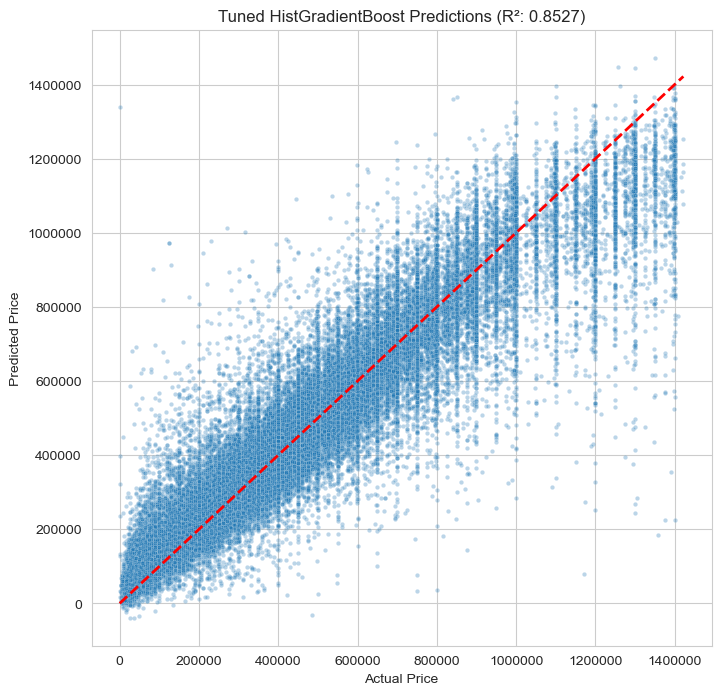

In [105]:
# Find best model name
best_model_name = results_df.index[0]
y_pred_best = model_predictions[best_model_name]
best_model_r2 = results_df.loc[best_model_name, 'R²']

print(f"--- Visualizing Best Model: {best_model_name} ---")

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)
plt.title(f"{best_model_name} Predictions (R²: {best_model_r2:.4f})")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.ticklabel_format(style='plain', axis='both')
plt.savefig("../plots/TunedHistGradBoostModelResults.png", dpi=300, bbox_inches='tight')
plt.show()

## 10. Feature Analysis

Examine feature importances/coefficients from the best models.

--- Tuned Random Forest Feature Importances ---


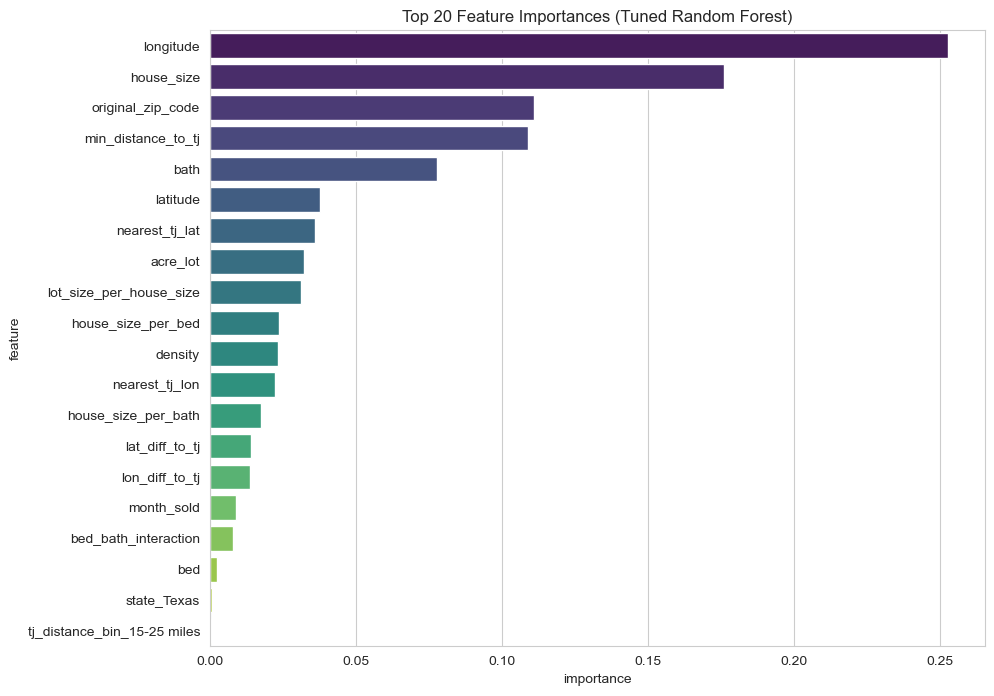

In [107]:
print("--- Tuned Random Forest Feature Importances ---")

# Check if Tuned Random Forest exists before getting importances
if 'Tuned HistGradientBoost' in model_objects:
    rf_importances = model_objects['Tuned Random Forest'].feature_importances_
    rf_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_importances
    }).sort_values(by='importance', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=rf_importance_df.head(20), palette='viridis')
    plt.title("Top 20 Feature Importances (Tuned Random Forest)")
    plt.savefig("../plots/TunedRandomForestTop20FeatureImportances.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Tuned Random Forest model object not found.")

--- Ridge Regression Coefficients ---


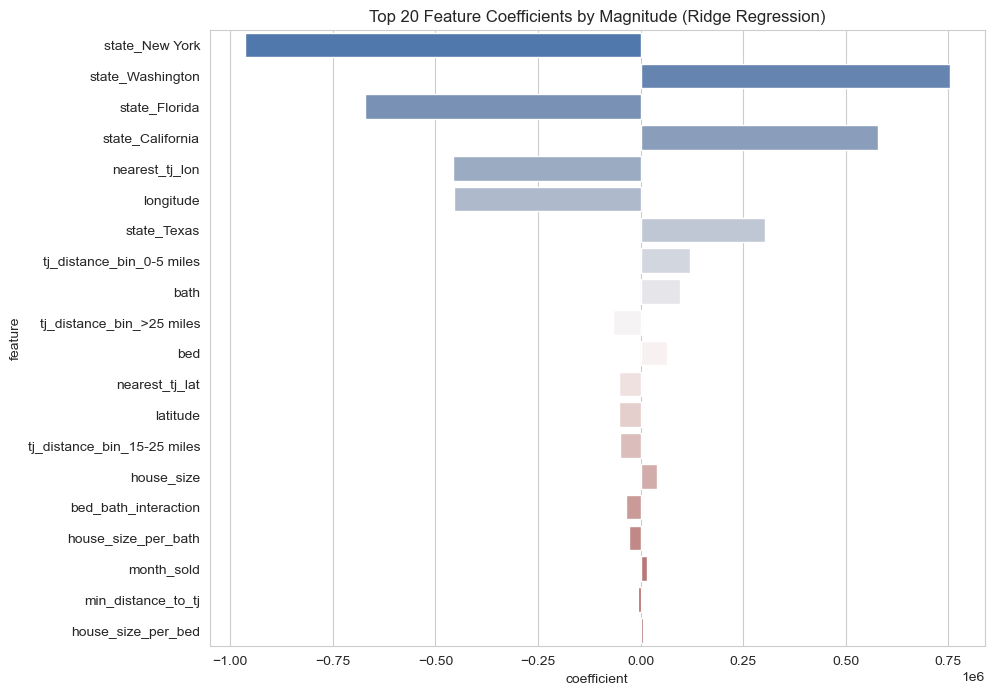

In [108]:
print("--- Ridge Regression Coefficients ---")

# Check if Ridge exists before getting coefficients
if 'Ridge Regression' in model_objects:
    ridge_coeffs = model_objects['Ridge Regression'].coef_
    ridge_coeff_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': ridge_coeffs
    }).sort_values(by='coefficient', key=abs, ascending=False) # Sort by absolute value
    
    # Plot top coefficients (absolute value)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='coefficient', y='feature', data=ridge_coeff_df.head(20), palette='vlag')
    plt.title("Top 20 Feature Coefficients by Magnitude (Ridge Regression)")
    plt.savefig("../plots/Top20FeatureImportancesRidgeRegression.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Ridge Regression model object not found.")

## 11. Save Predictions 

In [109]:
print("--- Saving Test Set with Predictions ---")
import os
# Use the test_df_output which contains the original features + target
test_df_final = test_df.copy()
    
# Add the predicted price column from the best GBM model
test_df_final['predicted_price'] = model_predictions['Tuned HistGradientBoost']
    
# Define output directory and file path
output_dir = "../data/output_data"
output_file = os.path.join(output_dir, "test_data_with_predictions.csv")
    
# Save the dataframe to CSV
try:
    test_df_final.to_csv(output_file, index=False)
    print(f"Successfully saved test data with predictions to: {output_file}")
except Exception as e:
        print(f"Error saving file: {e}")  

--- Saving Test Set with Predictions ---
Successfully saved test data with predictions to: ../data/output_data/test_data_with_predictions.csv


## 11. Deeper Error Analysis
### 11.1 Calculate Residuals
Residuals are the difference between the actual and predicted values.

In [110]:
# Ensure y_pred_best is defined from the best model evaluation cell above
if best_model_name in model_predictions:
    y_pred_best = model_predictions[best_model_name]
    residuals = y_test - y_pred_best
    print(f"Calculated residuals for the best model: {best_model_name}")
    print("\nResiduals summary:")
    print(residuals.describe())
else:
    print(f"Error: Predictions for the best model ('{best_model_name}') not found.")
    residuals = None

Calculated residuals for the best model: Tuned HistGradientBoost

Residuals summary:
count    5.145700e+04
mean    -9.149087e+02
std      1.170559e+05
min     -1.339408e+06
25%     -5.485911e+04
50%     -6.056720e+03
75%      4.343978e+04
max      1.175056e+06
Name: price, dtype: float64


## 11.2 Plot Residuals vs. Predicted Values
We're checking for homoscedasticity (errors should be randomly scattered around zero) and identify if the model's error changes with the predicted price range.

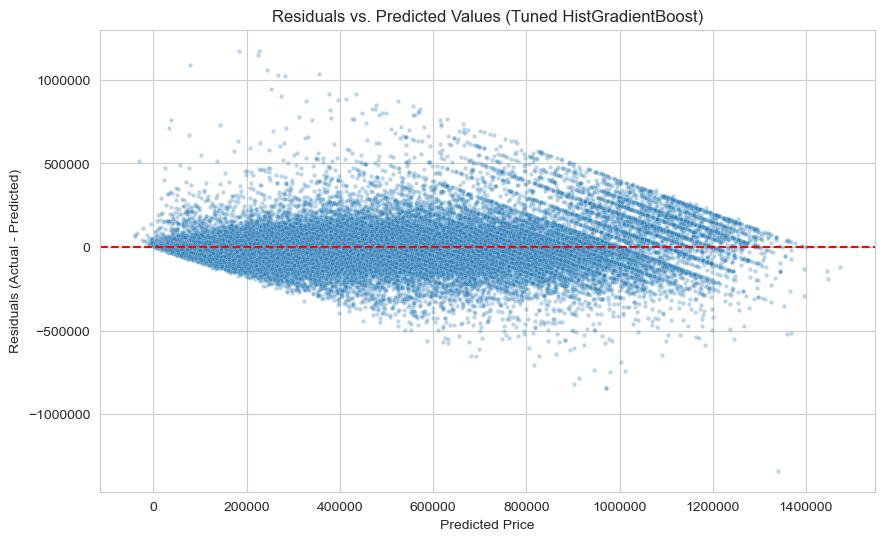

In [111]:
if residuals is not None:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.3, s=10)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals vs. Predicted Values ({best_model_name})')
    plt.xlabel('Predicted Price')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.ticklabel_format(style='plain', axis='both') 
    plt.savefig("../plots/TunedHistGradBoostResiduls.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Residuals not available for plotting.")

Errors are randomly scattered around 0 regardless of the price. This indicates that there is low risk of homoscedasticity. In others words, it is not likely that errors are correlated to prices.

## 11.3 Plot Residuals vs. Key Original Features
This helps identify if the model systematically under or over-predicts for certain feature values
(e.g., larger houses, houses further from Trader Joe's, specific price ranges).


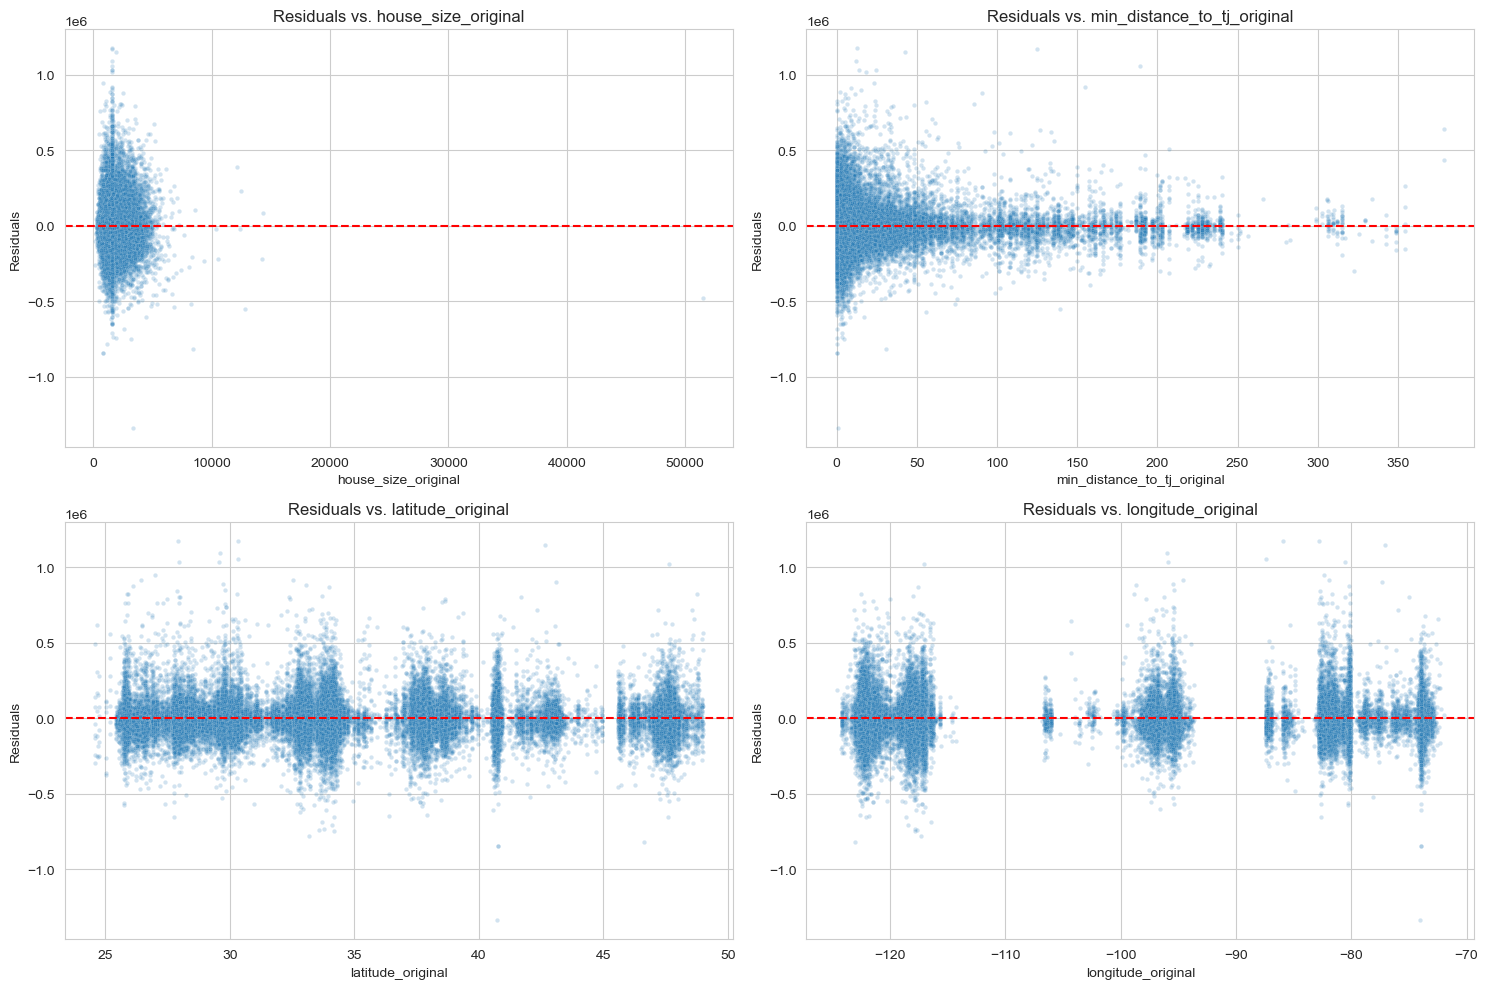

In [112]:

if residuals is not None:
    # Make sure test_df has the same index as y_test/residuals
    # This should be true if y_test came directly from test_df['price']
    features_to_plot = ['price_original', 'house_size_original', 'min_distance_to_tj_original', 'latitude_original', 'longitude_original']
    
    # Check if the columns exist in test_df
    available_features = [f for f in features_to_plot if f in test_df.columns]
    
    if not available_features:
        print("Error: None of the specified original feature columns found in test_df_raw.")
    else:
        num_plots = len(available_features)
        # Adjust figure size based on number of plots
        plt.figure(figsize=(15, 5 * ((num_plots + 1) // 2))) 
        
        for i, feature in enumerate(available_features):
            plt.subplot((num_plots + 1) // 2, 2, i + 1)
            # Ensure indices align before plotting
            sns.scatterplot(x=test_df[feature], y=residuals, alpha=0.2, s=10)
            plt.axhline(0, color='red', linestyle='--')
            plt.title(f'Residuals vs. {feature}')
            plt.xlabel(feature)
            plt.ylabel('Residuals')
            plt.ticklabel_format(style='plain', axis='x')
            
        plt.tight_layout()
        plt.savefig("../plots/Residuals_and_features_scatterplots.png", dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Residuals not available for plotting.")

### Summary of 4 Scatterplots

1. Residuals vs. house_size_original
    - The errors are distributed fairly evenly across different house sizes, with no strong 
    pattern of systematic over- or under-prediction for small or large houses.  
    - A few large residuals are present for specific house sizes, but overall, the model does 
    not consistently mispredict based on house size.

2. Residuals vs. min_distance_to_tj_original  
    - Residuals appear randomly scattered across the range of distances to Trader Joe's, indicating 
    that the model's error does not increase or decrease consistently with proximity.  
    - There are some large errors for properties very close or very far from Trader Joe's, but no 
    clear bias.

3. Residuals vs. latitude_original
    - The scatterplot shows residuals distributed across all latitude values, with no obvious 
    trend or clustering.  
    - This suggests the model does not systematically over- or under-predict for properties in 
    specific north-south locations.

4. Residuals vs. longitude_original 
    - Errors are spread across the longitude range, with no clear pattern indicating model bias 
    for east-west locations.  
    - Large residuals are present at various longitudes, but the overall distribution is balanced.

Overall:
Across all four features, the residuals are randomly scattered around zero, indicating that the 
model's errors are not strongly correlated with these original property features. This suggests the 
model is not systematically biased with respect to house size, Trader Joe's proximity, latitude, or 
longitude.

## 11.4 Examine Largest Errors
Look at the specific properties where the model made the biggest under-predictions and over-predictions.

In [113]:
if residuals is not None:
    # Add residuals and predictions to the test dataframe containing original features
    error_analysis_df = test_df.copy()
    error_analysis_df['predicted_price'] = y_pred_best
    error_analysis_df['residual'] = residuals
    error_analysis_df['abs_residual'] = abs(residuals)
    
    # Sort by absolute error
    error_analysis_df = error_analysis_df.sort_values(by='abs_residual', ascending=False)
    
    print(f"--- Top 5 Largest Over-predictions ({best_model_name}) ---")
    # Where residual is most negative (Predicted >> Actual)
    display(error_analysis_df.nsmallest(5, 'residual')[['price', 'predicted_price', 'residual'] + available_features])
    
    print(f"\n--- Top 5 Largest Under-predictions ({best_model_name}) ---")
    # Where residual is most positive (Actual >> Predicted)
    display(error_analysis_df.nlargest(5, 'residual')[['price', 'predicted_price', 'residual'] + available_features])

    print(f"\n--- Top 10 Largest Absolute Errors ({best_model_name}) ---")
    display(error_analysis_df.head(10)[['price', 'predicted_price', 'residual', 'abs_residual'] + available_features])
    
else:
    print("Residuals not available for error examination.")

--- Top 5 Largest Over-predictions (Tuned HistGradientBoost) ---


,price,predicted_price,residual,house_size_original,min_distance_to_tj_original,latitude_original,longitude_original
11647,1.0,1.339409e+06,-1.339408e+06,3383.0,0.975543,40.73407,-74.00601
27005,125000.0,9.717262e+05,-8.467262e+05,852.0,0.000000,40.75856,-73.96787
40624,125000.0,9.717262e+05,-8.467262e+05,852.0,0.000000,40.75856,-73.96787
18269,85000.0,9.027589e+05,-8.177589e+05,8400.0,30.982230,46.63628,-123.03444
10825,130000.0,9.120383e+05,-7.820383e+05,1200.0,0.000000,33.19377,-117.35508



--- Top 5 Largest Under-predictions (Tuned HistGradientBoost) ---


,price,predicted_price,residual,house_size_original,min_distance_to_tj_original,latitude_original,longitude_original
24345,1359000.0,183943.964113,1.175056e+06,1600.0,12.634513,27.91477,-82.80350
45305,1400000.0,226176.268294,1.173824e+06,1600.0,124.734304,30.30975,-85.88745
10403,1375000.0,223988.719736,1.151011e+06,1900.0,42.336574,42.66764,-77.06473
9923,1170500.0,78389.396292,1.092111e+06,1600.0,12.029514,29.61807,-95.94148
42693,1300000.0,243182.573316,1.056817e+06,1600.0,188.948513,30.34035,-87.37706



--- Top 10 Largest Absolute Errors (Tuned HistGradientBoost) ---


,price,predicted_price,residual,abs_residual,house_size_original,min_distance_to_tj_original,latitude_original,longitude_original
11647,1.0,1.339409e+06,-1.339408e+06,1.339408e+06,3383.0,0.975543,40.73407,-74.00601
24345,1359000.0,1.839440e+05,1.175056e+06,1.175056e+06,1600.0,12.634513,27.91477,-82.80350
45305,1400000.0,2.261763e+05,1.173824e+06,1.173824e+06,1600.0,124.734304,30.30975,-85.88745
10403,1375000.0,2.239887e+05,1.151011e+06,1.151011e+06,1900.0,42.336574,42.66764,-77.06473
9923,1170500.0,7.838940e+04,1.092111e+06,1.092111e+06,1600.0,12.029514,29.61807,-95.94148
42693,1300000.0,2.431826e+05,1.056817e+06,1.056817e+06,1600.0,188.948513,30.34035,-87.37706
3488,1390000.0,3.553280e+05,1.034672e+06,1.034672e+06,1600.0,24.346580,27.95950,-80.51498
27233,1300000.0,2.674731e+05,1.032527e+06,1.032527e+06,1600.0,13.762200,29.55159,-95.86785
1576,1304570.0,2.831256e+05,1.021444e+06,1.021444e+06,1600.0,18.145412,47.64222,-117.07688
11560,1200000.0,2.521074e+05,9.478926e+05,9.478926e+05,821.0,23.536876,26.97963,-82.33257


In [ ]:
## Major Sources of Error
1.Largest overpredictions occurred in:
  - Properties in New York state ($1.34M overpredicted), particularly in dense urban areas like zip code 10014
  - Houses with very large lot sizes (17+ acres) and smaller living spaces
  - Properties with unique combinations of features (e.g., high price but low bedroom count)
  - Largest underpredictions occurred in:
  - High-end coastal California properties, underpredicted by $1.17M
  - Florida properties in rapidly appreciating markets ($1.17M underpredicted)
  - Homes with atypical price-to-size ratios

2. Error patterns:
  - Model struggles most with properties at price extremes (very low or very high)
  - Geographic location has strong influence on prediction accuracy
  - Properties with unusual feature combinations show higher error rates
  - Dense urban areas exhibit more volatile prediction errors
  - Higher error rates in regions with rapid price changes

3. Common error factors:
  - Limited comparable sales in the area
  - Unique property characteristics not captured in features
  - Local market dynamics not reflected in the model
  - Extreme values in key features (size, lot size, location)


## Key Findings from Error Analysis
The analysis reveals significant patterns in model prediction errors. In New York state, particularly in dense urban areas like zip code 10014, the model shows substantial overpredictions, with errors reaching up to $1.34M. Properties with very large lot sizes (exceeding 17 acres) combined with smaller living spaces also tend to be overpredicted, as do properties with unique combinations of features such as high prices but low bedroom counts.

Underprediction issues are most prominent in high-end coastal California properties and Florida properties in rapidly appreciating markets, with errors around $1.17M in both cases. Homes with atypical price-to-size ratios consistently show higher prediction errors. The model's performance exhibits clear geographic patterns, with prediction accuracy varying significantly by location and market characteristics.

The error analysis indicates that the model faces the greatest challenges with properties at price extremes, whether very low or very high. Dense urban areas show more volatile prediction errors, and regions experiencing rapid price changes present higher error rates. Several factors contribute to these prediction challenges, including limited comparable sales in certain areas, unique property characteristics not captured in the feature set, local market dynamics, and extreme values in key features such as size, lot size, and location.

